# **ProtGPT3-MSA MODEL**

**Notebook developed by Núria Mimbrero.**

* ProtGPT3 is a new family of protein language models we are training in our lab. ProtGPT3-MSA is a protein language model trained by grouping similar proteins through Multiple Sequence Alignments (MSAs). This way, we can generate desired enzymes by prompting with an MSA of sequences corresponding to the specific protein family we aim to design.

* Prompting with homolog sequences instead of fine-tuning the base model improves performance for unrepresented protein families and avoids the need to retrain the model.

## Example: **Design of defluorinases using the ProtGPT3-MSA model**
* Few natural defluorinases are known. We will use these natural sequences as the MSA prompt for ProtGPT3-MSA to generate novel defluorinase candidates.

> **Tip:** Make sure the runtime is set to **GPU** (`Runtime` → `Change runtime type` → `T4 GPU` or better).

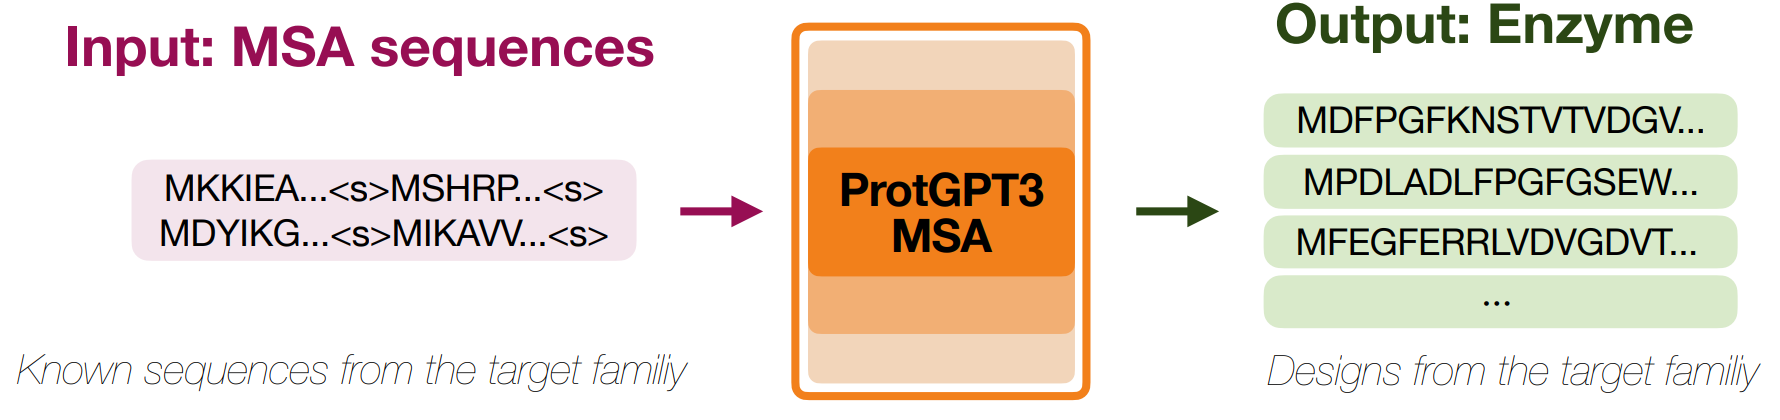

## Example: **Design of defluorinases using ProtGPT3-MSA model**
*  Few natural defluorinases are known. These ones will be used to generate the MSA that will be prompted to ProtGPT3-MSA model.

## **1. Download model and example sequences**

We download the ProtGPT3-MSA-nano weights and the example defluorinases FASTA from Google Drive.

In [ ]:
!pip -q install -U gdown

# Example fasta sequences
!mkdir -p /content/fasta_sequences
!gdown --folder "https://drive.google.com/drive/folders/16hgylf-NrOUhhiySkRo8tpcZiGSBz0Gy" -O /content/fasta_sequences

## **2. Install required Python packages**

In [ ]:
!pip -q install biopython transformers torch sentencepiece

## **3. Import modules**

In [ ]:
from typing import List
import os
import re
import random

from Bio import SeqIO
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## **4. Prompt formatting**
* `ProtGPT3-MSA` was trained with two different modalities `<gap>` and `<no_gap>`, which allow the model to respectively process/generate aligned and unaligned homologous seqeuences. Therefore, as a first step, we need to decide with which of the two modalities we would like to prompt `ProtGPT3-MSA`.
The modality is control via two special tokens which must be placed at the start of the concatenated protein sequences to inform the model in which modalities we are passing the sequences.
In the example below, we use unaligned homologs (i.e., `<no_gap>`) to prompt the model. However, you can use aligned sequences, by setting `gap=True` in the `build_prompt()` method defined below, which will build the prompt with special token for aligned sequences. Importantly, in that case, the input `sequences` that you're passing to `build_prompt()` must be **aligned** (i.e., containing gaps and all having the same length).

In [ ]:
def process_style(seq: str) -> str:
    """Strip gaps, drop X residues, uppercase the rest."""
    return re.sub(r"[X]", "", seq.replace("-", "").upper())

def build_prompt(sequences: List[str], gap: bool = False, direction: str = "1") -> str:
    """Build the DAYHOFF/MSA prompt in the same token order used during training."""
    if gap:
      gap_token="<gap>"
      assert all(len(s) == len(sequences[0]) for s in sequences), "Sequences in the prompt have different len(), but should be aligned, either align them or use no_gap mode"
    else:
      gap_token = "<no_gap>"

    assert len(sequences) <= 15, "The model cannot be prompted with more than 15 sequences (i.e., reduce the number of sequences to 15 or less)"

    tokens: List[str] = ["<|bos|>", direction, gap_token]
    for seq in sequences:
        # add separator token to mark boundaries between sequences
        tokens.append("<s>")
        tokens.extend(list(process_style(seq)))

    # Separator before the continuation that the model will generate
    tokens.append("<s>")
    return " ".join(tokens)


* You may have noticed `build_prompt` takes an additional input argument called `direction`. This allows `ProtGPT3-MSA` to generate in forward (i.e., N-to-C `direction="1"`) and reversed (i.e., C-to-N, `direction="2"`) directions. In the example below, we generate all sequences in forward (N-to-C) direction. Nevertheless, to generate in the reversed (C-to-N) direction, you can simply pass `direction="2"` to `build_prompt`. Importantly, in that case, your input `sequences` **must** be pass to `build_prompt` in the reversed direction.
* The direction modalitiy is compatible with both `<gap>` and `<no_gap>` modalities.   

## **5. Build the prompt from the input FASTA**

The model was trained with up to **15 homologs per prompt**, so if your FASTA contains more sequences we randomly subsample 15 of them.

In [ ]:
fasta_file = "/content/fasta_sequences/confirmed_defluorinases.fasta"
output_fasta_file = "/content/fasta_sequences/prompt_used"
sequences = [str(record.seq) for record in SeqIO.parse(fasta_file, "fasta")]
print(f"Loaded {len(sequences)} sequences from {os.path.basename(fasta_file)}")

"""
if len(sequences) > 15:
    sequences = random.sample(sequences, 15)
    print(f"Subsampled to {len(sequences)} sequences for the prompt")
"""


prompt = build_prompt(sequences)
print("\n--- Prompt preview (first 400 chars) ---\n")
print(prompt[:400], "...")

## **6. Functions for generation and perplexity scoring**   
* `compute_per_sequence_perplexity` scores every generated sequence in a single batched forward pass. Lower perplexity → the model is more confident the sequence is plausible.
* `run_generation` builds the prompt, generates `num_generation_sequences × num_batches` candidates, scores them, and saves them to a FASTA file sorted from best (lowest perplexity) to worst.

**Perplexity**

In [ ]:
def compute_per_sequence_perplexity(
    model,
    output_ids: torch.Tensor,        # [N, total_len] returned by model.generate()
    prompt_len: int,
    stop_token_ids: List[int],       # e.g. [eos_token_id, <s>_token_id]
    pad_token_id: int,
):
    """Per-sequence perplexity over the *generated* sequence (per sequence)

    Only tokens generated by the model are scored (the prompt is ignored). For
    each row we count tokens from position `prompt_len` up to and including the
    first stop token (eos or <s>); any padding that appears after the stop is
    excluded so different sequence lengths are handled correctly.

    Returns a dict with three [N]-shaped tensors:
      - perplexity:    lower = the model found the sequence more likely
      - mean_log_prob: mean per-token log-probability (higher = more confident)
      - n_tokens:      number of generated tokens that were actually scored
    """
    device = output_ids.device
    N, total_len = output_ids.shape
    gen_len = total_len - prompt_len
    if gen_len <= 0:
        raise ValueError("No generated tokens to score (prompt_len >= total_len).")

    attention_mask = (output_ids != pad_token_id).long()

    with torch.no_grad():
        out = model(
            input_ids=output_ids,
            attention_mask=attention_mask,
            use_cache=False,
        )

    # The token at position t is predicted by the logits at position t-1, so to
    # score positions [prompt_len, total_len-1] we slice logits at [prompt_len-1, total_len-2].
    logits  = out.logits[:, prompt_len - 1 : total_len - 1, :]   # [N, gen_len, V]
    targets = output_ids[:, prompt_len:total_len]                 # [N, gen_len]

    # Build a mask over the generated portion: keep positions up to and including
    # the first stop token, drop everything after.
    stop_tensor = torch.tensor(sorted(set(stop_token_ids)), device=device)
    is_stop = torch.isin(targets, stop_tensor)                    # [N, gen_len]
    has_stop = is_stop.any(dim=1)
    first_stop_idx = is_stop.int().argmax(dim=1)                  # 0 if no stop, but masked below
    length = torch.where(
        has_stop,
        first_stop_idx, # exclude stop codon
        torch.full((N,), gen_len, device=device, dtype=torch.long),
    )
    positions = torch.arange(gen_len, device=device).unsqueeze(0)  # [1, gen_len]
    stop_mask = (positions < length.unsqueeze(1)).float()           # [N, gen_len]
    pad_mask  = (targets != pad_token_id).float()                   # [N, gen_len]
    mask      = stop_mask * pad_mask                                # [N, gen_len]

    # Cast to float32 before log_softmax — bf16 log_softmax is noisy.
    log_probs = F.log_softmax(logits.float(), dim=-1)             # [N, gen_len, V]
    token_lp  = log_probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)  # [N, gen_len]

    token_lp_masked = token_lp * mask
    n_tokens = mask.sum(dim=-1).clamp(min=1)
    mean_lp  = token_lp_masked.sum(dim=-1) / n_tokens             # [N]

    perplexity = torch.exp(-mean_lp)                              # [N]
    return {
        "perplexity": perplexity,
        "mean_log_prob": mean_lp,
        "n_tokens": n_tokens.long(),
    }

In [ ]:
# code to score perplexity of the cleaned sequence
def clean_completion_text(text: str) -> str:
    """
    Clean generated text into the final amino-acid sequence you want to save.

    This follows your current logic:
    - remove <s>
    - remove spaces
    - remove gaps '-'
    - uppercase
    - remove X
    """
    text = text.replace("<s>", "")
    text = text.replace(" ", "")
    text = text.replace("-", "")
    text = text.upper()
    text = re.sub(r"[X]", "", text)
    return text


def format_sequence_for_protgpt3_msa(seq: str) -> str:
    """
    Convert a clean amino-acid sequence into the spaced format expected by the model:
    MEKPR -> M E K P R
    """
    return " ".join(list(seq))


def compute_cleaned_sequence_perplexity(
    model,
    tokenizer,
    prompt: str,
    cleaned_sequences: List[str],
    pad_token_id: int,
):
    """
    Compute perplexity of the cleaned amino-acid sequences only.

    This scores:

        P(cleaned_sequence | MSA_prompt)

    It does NOT score:
    - the prompt
    - the raw generated gaps
    - spaces
    - the stop token <s>
    - padding

    Returns:
      perplexity:    [N]
      mean_log_prob: [N]
      n_tokens:      [N]
    """
    device = next(model.parameters()).device

    # Tokenize the prompt once.
    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    )["input_ids"][0].to(device)

    prompt_len = prompt_ids.shape[0]

    input_rows = []
    completion_lengths = []

    for seq in cleaned_sequences:
        seq = clean_completion_text(seq)

        if len(seq) == 0:
            continue

        completion_text = format_sequence_for_protgpt3_msa(seq)

        completion_ids = tokenizer(
            completion_text,
            return_tensors="pt",
            add_special_tokens=False,
        )["input_ids"][0].to(device)

        full_ids = torch.cat([prompt_ids, completion_ids], dim=0)

        input_rows.append(full_ids)
        completion_lengths.append(completion_ids.shape[0])

    if len(input_rows) == 0:
        return {
            "perplexity": torch.empty(0, device=device),
            "mean_log_prob": torch.empty(0, device=device),
            "n_tokens": torch.empty(0, dtype=torch.long, device=device),
        }

    completion_lengths = torch.tensor(
        completion_lengths,
        dtype=torch.long,
        device=device,
    )

    # Pad batch manually.
    max_len = max(row.shape[0] for row in input_rows)
    input_ids = torch.full(
        (len(input_rows), max_len),
        fill_value=pad_token_id,
        dtype=torch.long,
        device=device,
    )

    attention_mask = torch.zeros(
        (len(input_rows), max_len),
        dtype=torch.long,
        device=device,
    )

    for i, row in enumerate(input_rows):
        input_ids[i, : row.shape[0]] = row
        attention_mask[i, : row.shape[0]] = 1

    with torch.no_grad():
        out = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
        )

    # Standard causal-LM shift:
    # logits at position t predict token at position t+1.
    logits = out.logits[:, :-1, :]      # [N, max_len - 1, vocab]
    targets = input_ids[:, 1:]          # [N, max_len - 1]

    # Absolute positions of the target tokens.
    # targets[:, j] corresponds to original input position j + 1.
    target_positions = torch.arange(
        1,
        max_len,
        device=device,
    ).unsqueeze(0)  # [1, max_len - 1]

    # Score only the cleaned completion tokens:
    # original positions prompt_len ... prompt_len + completion_len - 1
    score_mask = (
        (target_positions >= prompt_len)
        &
        (target_positions < prompt_len + completion_lengths.unsqueeze(1))
    ).float()

    log_probs = F.log_softmax(logits.float(), dim=-1)
    token_lp = log_probs.gather(
        dim=-1,
        index=targets.unsqueeze(-1),
    ).squeeze(-1)

    token_lp_masked = token_lp * score_mask

    n_tokens = score_mask.sum(dim=-1).clamp(min=1)
    mean_lp = token_lp_masked.sum(dim=-1) / n_tokens

    perplexity = torch.exp(-mean_lp)

    return {
        "perplexity": perplexity,
        "mean_log_prob": mean_lp,
        "n_tokens": n_tokens.long(),
    }

**Generate sequences**

In [ ]:
def run_generation(
    prompt_fasta_file,
    output_fasta_file,
    model_path,
    num_generation_sequences,
    num_batches,
    temperature,
    top_p,
    max_new_tokens=None,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    sequences = [str(record.seq) for record in SeqIO.parse(prompt_fasta_file, "fasta")]
    print(f"Loaded {len(sequences)} sequences")

    # The model was trained with up to 15 homologs per prompt; subsample if needed.
    if len(sequences) > 15:
        sequences = random.sample(sequences, 15)
        print(f"Subsampled to {len(sequences)} sequences for the prompt")

    # max_new_tokens follows the developer's recommendation: longest homolog + 50 aa margin.
    if max_new_tokens is None:
        max_new_tokens = max(len(s) for s in sequences) + 50

    prompt = build_prompt(sequences)

    tokenizer = AutoTokenizer.from_pretrained(
            model_path,
            add_eos_token=False,
            add_bos_token=False,
            use_fast=True
        )
    tokenizer.padding_side ="left"

    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32
    ).to(device).eval()


    # Use the direct vocab lookup so we don't depend on how `encode` handles the leading token.
    s_token_id = tokenizer.convert_tokens_to_ids("<s>")
    eos_id_for_termination = [tokenizer.eos_token_id, s_token_id] # stop generation after generating a single sequence
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)
    prompt_len = input_ids.shape[1]

    all_records = []  # list of (sequence_text, perplexity, n_scored_tokens)

    for _ in range(num_batches):
        with torch.no_grad():
            output = model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_p=top_p,
                num_return_sequences=num_generation_sequences,
                eos_token_id=eos_id_for_termination,
                pad_token_id=pad_token_id,
            )

        # Score the generated portion of each sequence with a single batched forward pass.
        # First decode and clean the generated sequences.
        batch_cleaned_sequences = []

        for i in range(output.shape[0]):
            completion_ids = output[i][prompt_len:]

            completion_text = tokenizer.decode(
                completion_ids,
                skip_special_tokens=True,
            ).strip()

            cleaned_seq = clean_completion_text(completion_text)

            if cleaned_seq:
                batch_cleaned_sequences.append(cleaned_seq)

        # Now compute perplexity of the cleaned sequences only.
        if batch_cleaned_sequences:
            ppl_info = compute_cleaned_sequence_perplexity(
                model=model,
                tokenizer=tokenizer,
                prompt=prompt,
                cleaned_sequences=batch_cleaned_sequences,
                pad_token_id=pad_token_id,
            )

            perplexities = ppl_info["perplexity"].tolist()
            n_scored = ppl_info["n_tokens"].tolist()

            for seq, ppl, n_tok in zip(batch_cleaned_sequences, perplexities, n_scored):
                all_records.append((seq, ppl, n_tok))



    # Sort by perplexity (lowest first = highest model confidence).
    all_records.sort(key=lambda r: r[1])

    with open(output_fasta_file, "w") as f:
        for i, (seq, ppl, n_tok) in enumerate(all_records):
            f.write(f">seq{i} perplexity={ppl:.4f} n_scored_tokens={n_tok} length={len(seq)}\n{seq}\n")

    if all_records:
        ppls = [r[1] for r in all_records]
        print(f"Saved {len(all_records)} sequences to {output_fasta_file} "
              f"(perplexity min/median/max = {min(ppls):.3f} / {sorted(ppls)[len(ppls)//2]:.3f} / {max(ppls):.3f})")
    else:
        print(f"Saved 0 sequences to {output_fasta_file}")


**7. Generate sequences similar to the MSA sequences we defined using ProtGPT3-MSA**

In [ ]:
model_path = "AI4PD/ProtGPT3-MSA" # Define the model we want to use
input_fasta = "/content/fasta_sequences/confirmed_defluorinases.fasta" # Define the fasta file containing the sequences we will use to prompt the model
output_base = "/content/data/output_generation" # Define the output folder where to store the generated sequences

# create output folder
os.makedirs(output_base, exist_ok=True)

temperatures = [0.8, 0.9, 1.0]
top_ps = [0.8, 0.9, 1.0]

os.makedirs(output_base, exist_ok=True)

for temperature in temperatures:
    for top_p in top_ps:
        output_file = os.path.join(
            output_base,
            f"temperature_{temperature}_top_p_{top_p}.fasta",
            )
        run_generation(
            prompt_fasta_file=input_fasta,
            output_fasta_file=output_file,
            model_path=model_path,
            num_generation_sequences=10,
            num_batches=4,
            temperature=temperature,
            top_p=top_p,
            )
        print(f"Generated {output_file}")

## **How does the generation work?**
A decoder-only transformer generates text (in this case protein sequences) **one token after the other**. This is what is called **autoregressive generation**.
* Each token is generated based on all previously generated tokens. P(Xt|previous tokens)

GENERATION WORKFLOW:
1. Input tokens -> model
2. Model output scores for each vocabulary token
3. Choose the next token
4. Repeat

### **How can we control how to choose the next token?**
Then next token can be selected using different sampling strategies controlled by the **hypeparameters**, adjusting between more predictable or more diverse.
* **Tempeature**: controls randomness:
  * Low= deterministic, repetitive
  * High: more random, creative
* **Top-k sampling**: indicates the number of most probable tokens to sample from.
  * Top-k=10: sample from the 10 tokens with higher probability.  
* **Top-p sampling**: indicates the cumulative probability of tokens where to sample from.
  * Top-p=0.3: sample from all the top tokens whose probability summs up to 0.3.


useful links for more detailed explanation:
* https://huggingface.co/blog/how-to-generate
* https://huggingface.co/docs/transformers/llm_tutorial

In [ ]:
# Compute perplexity for a given sequence and prompt
from typing import List, Dict
import re
import random

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM


def clean_protein_sequence(seq: str) -> str:
    """
    Clean a protein sequence in the same spirit as your ProtGPT3-MSA code.

    Removes:
      - <s>
      - whitespace
      - gaps "-"
      - X residues

    Returns uppercase sequence.
    """
    seq = seq.replace("<s>", "")
    seq = re.sub(r"\s+", "", seq)
    seq = seq.replace("-", "")
    seq = seq.upper()
    seq = seq.replace("X", "")
    return seq



def score_sequence_perplexity_protgpt3_msa(
    model,
    tokenizer,
    homolog_sequences: List[str],
    target_sequence: str,
    device: torch.device | str | None = None,
    shuffle_prompt: bool = False,
    seed: int | None = 0,
) -> Dict[str, float]:
    """
    Compute perplexity of one cleaned target protein sequence conditioned on
    a ProtGPT3-MSA homolog prompt.

    This scores:

        P(target_sequence | MSA prompt)

    It does NOT score:
      - the prompt homologs
      - a final <s> stop token
      - gaps
      - spaces
      - X residues

    Returns:
      {
        "sequence": cleaned sequence,
        "perplexity": float,
        "mean_log_prob": float,
        "n_scored_tokens": int,
      }
    """

    if device is None:
        device = next(model.parameters()).device
    else:
        device = torch.device(device)

    model = model.to(device).eval()

    pad_token_id = (
        tokenizer.pad_token_id
        if tokenizer.pad_token_id is not None
        else tokenizer.eos_token_id
    )

    if pad_token_id is None:
        raise ValueError(
            "Tokenizer has no pad_token_id or eos_token_id. "
            "Please define tokenizer.pad_token before scoring."
        )

    # 1. Clean target sequence
    cleaned_seq = clean_protein_sequence(target_sequence)

    if len(cleaned_seq) == 0:
        raise ValueError("Target sequence is empty after cleaning.")

    # 2. Build fixed MSA prompt
    prompt = build_prompt(
        homolog_sequences=homolog_sequences,
        shuffle=shuffle_prompt,
        max_homologs=15,
        seed=seed,
    )

    # 3. ProtGPT3-MSA expects spaced amino-acid tokens
    target_text = " ".join(list(cleaned_seq))

    # 4. Tokenize prompt and target separately so we know exactly where target starts
    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    )["input_ids"].to(device)

    target_ids = tokenizer(
        target_text,
        return_tensors="pt",
        add_special_tokens=False,
    )["input_ids"].to(device)

    prompt_len = prompt_ids.shape[1]
    target_len = target_ids.shape[1]

    # 5. Concatenate prompt + target
    input_ids = torch.cat([prompt_ids, target_ids], dim=1)

    attention_mask = torch.ones_like(input_ids, dtype=torch.long, device=device)

    with torch.no_grad():
        out = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
        )

    # 6. Causal LM shift:
    # token at position t is scored by logits at position t-1.
    #
    # Target tokens are at positions:
    # prompt_len ... prompt_len + target_len - 1
    #
    # Therefore, use logits:
    # prompt_len - 1 ... prompt_len + target_len - 2
    logits = out.logits[:, prompt_len - 1 : prompt_len + target_len - 1, :]
    targets = input_ids[:, prompt_len : prompt_len + target_len]

    log_probs = F.log_softmax(logits.float(), dim=-1)

    token_log_probs = log_probs.gather(
        dim=-1,
        index=targets.unsqueeze(-1),
    ).squeeze(-1)

    mean_log_prob = token_log_probs.mean()

    perplexity = torch.exp(-mean_log_prob)

    return {
        "sequence": cleaned_seq,
        "perplexity": float(perplexity.detach().cpu()),
        "mean_log_prob": float(mean_log_prob.detach().cpu()),
        "n_scored_tokens": int(target_len),
    }

In [ ]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    add_eos_token=False,
    add_bos_token=False,
    use_fast=True,
)
tokenizer.padding_side="left"

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
).to(device).eval()

In [ ]:

# Define here the sequences used for prompting
homolog_sequences = [
    "seq1",
    "seq2",
    "seq3",
    "...",
]

# Define here the designed sequence you aim for scoring
sequence_to_score = "sequence_generated"

result = score_sequence_perplexity_protgpt3_msa(
    model=model,
    tokenizer=tokenizer,
    homolog_sequences=homolog_sequences,
    target_sequence=sequence_to_score,
    device=device,
    shuffle_prompt=False,
    seed=0,
)

print(result)